# 🧠 FedBioXAI v3 — Best Model
## Upgrades over v2 (Stable):
- ✅ **Step 1:** Real EEG-derived labels (theta/alpha ratio) instead of synthetic time-based labels
- ✅ **Step 2:** FedProx instead of FedAvg — handles non-IID subject data
- ✅ **Step 3:** Temporal LSTM layer — captures progressive drowsiness patterns across windows

```
EDF → Signal Extraction → [ECG Expert | EEG Expert | EOG Expert]
                                  ↓            ↓           ↓
                            [  Attention Gate (learned weights)  ]
                                          ↓
                               Fused Window Embedding
                                          ↓
                            [ Temporal LSTM over window sequence ]
                                          ↓
                                   Drowsy / Alert
                                          ↑
                    FedProx: each subject trains locally with proximal term
```

## 📦 Step 1: Install Dependencies

In [1]:
# No flwr or ray needed — pure PyTorch federated implementation
!pip install pyedflib matplotlib imbalanced-learn torch torchvision scikit-learn scipy numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 57.0 MB/s eta 0:00:00


## 📚 Step 2: Imports

In [2]:
import pyedflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os, copy, warnings
warnings.filterwarnings('ignore')

from scipy import signal as scipy_signal
from scipy.fft import fft, fftfreq
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Device
try:
    import torch_directml
    device = torch_directml.device()
    print('✅ Using AMD GPU via DirectML')
except ImportError:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'✅ Using device: {device}')

✅ Using device: cuda


## 📂 Step 3: Load EDF Files

In [3]:
# ─── CONFIG ───────────────────────────────────────────────────────────
EDF_FOLDER   = 'lol'   # folder with .edf files
WINDOW_SEC   = 30      # window length in seconds
STRIDE_SEC   = 5       # stride between windows
FS           = 128     # sampling rate Hz
SEQ_LEN      = 6       # how many consecutive windows the LSTM sees (= 30s context)
# ──────────────────────────────────────────────────────────────────────

def load_edf_file(filepath):
    try:
        f = pyedflib.EdfReader(filepath)
        if f.signals_in_file == 0:
            f.close(); return None, None, None
        labels  = f.getSignalLabels()
        fs      = f.getSampleFrequency(0)
        signals = {lbl: f.readSignal(i) for i, lbl in enumerate(labels)}
        f.close()
        return signals, labels, fs
    except Exception as e:
        print(f'  ✗ Error: {e}')
        return None, None, None

edf_files = sorted(glob(f'{EDF_FOLDER}/*.edf'))
print(f'Found {len(edf_files)} EDF files')

all_signals, file_info = [], []
skipped = 0
for path in edf_files:
    sig, lbl, fs = load_edf_file(path)
    if sig is not None:
        dur = len(list(sig.values())[0]) / fs
        all_signals.append(sig)
        file_info.append({
            'filename': os.path.basename(path),
            'labels': lbl, 'sample_rate': fs, 'duration_sec': dur
        })
        print(f'  ✓ {os.path.basename(path)} — {len(lbl)} ch — {dur/60:.1f} min')
    else:
        skipped += 1

print(f'\nLoaded {len(all_signals)} files | Skipped {skipped} annotation/empty files')

Found 40 EDF files
  ✓ 01M_1.edf — 7 ch — 121.8 min
  ✓ 01M_2.edf — 7 ch — 121.2 min
  ✓ 02F_1.edf — 7 ch — 123.0 min
  ✓ 02F_2.edf — 7 ch — 121.0 min
  ✓ 03F_1.edf — 7 ch — 121.8 min
  ✓ 03F_2.edf — 7 ch — 122.5 min
  ✓ 04M_1.edf — 7 ch — 115.5 min
  ✓ 04M_2.edf — 7 ch — 120.2 min
  ✓ 05M_1.edf — 7 ch — 120.8 min
  ✓ 05M_2.edf — 7 ch — 120.8 min
  ✓ 06M_1.edf — 7 ch — 120.2 min
  ✓ 06M_2.edf — 7 ch — 122.2 min
  ✓ 07F_1.edf — 7 ch — 121.5 min
  ✓ 07F_2.edf — 7 ch — 121.2 min
  ✓ 08M_1.edf — 7 ch — 120.5 min
  ✓ 08M_2.edf — 7 ch — 120.5 min
  ✓ 09M_1.edf — 7 ch — 120.5 min
  ✓ 09M_2.edf — 7 ch — 120.8 min
  ✓ 10M_1.edf — 7 ch — 120.5 min
  ✓ 10M_2.edf — 7 ch — 120.8 min

Loaded 20 files | Skipped 20 annotation/empty files


## 🔬 Step 4: Feature Extraction (ECG / EEG / EOG)

In [4]:
def extract_ecg_features(ecg, fs=128):
    feat = {}
    thresh = np.mean(ecg) + 2 * np.std(ecg)
    peaks, _ = scipy_signal.find_peaks(ecg, height=thresh, distance=int(fs * 0.5))
    if len(peaks) > 1:
        rr = np.diff(peaks) / fs * 1000
        feat['mean_hr']  = 60000 / np.mean(rr)
        feat['sdnn']     = np.std(rr)
        feat['rmssd']    = np.sqrt(np.mean(np.diff(rr)**2)) if len(rr) > 1 else 0
        feat['pnn50']    = np.sum(np.abs(np.diff(rr)) > 50) / len(rr) if len(rr) > 1 else 0
        feat['hr_range'] = np.max(rr) - np.min(rr)
    else:
        feat.update({'mean_hr': 0, 'sdnn': 0, 'rmssd': 0, 'pnn50': 0, 'hr_range': 0})
    return feat


def extract_eeg_features(eeg, fs=128):
    fv = np.abs(fft(eeg))
    ff = fftfreq(len(eeg), 1/fs)
    def band(lo, hi): return np.mean(fv[(ff >= lo) & (ff < hi)])
    delta = band(0.5, 4); theta = band(4, 8)
    alpha = band(8, 13);  beta  = band(13, 30); gamma = band(30, 45)
    return {
        'delta':        delta,
        'theta':        theta,
        'alpha':        alpha,
        'beta':         beta,
        'gamma':        gamma,
        'theta_alpha':  theta / alpha   if alpha > 0 else 0,
        'delta_alpha':  delta / alpha   if alpha > 0 else 0,
        'spectral_edge': ff[np.where(np.cumsum(fv) / np.sum(fv) >= 0.95)[0][0]] if np.sum(fv) > 0 else 0,
    }


def extract_eog_features(eog, fs=128):
    vel = np.abs(np.diff(eog))
    thr = np.mean(vel) + 2 * np.std(vel)
    return {
        'blink_rate':     np.sum(vel > thr) / (len(eog) / fs / 60),
        'mean_velocity':  np.mean(vel),
        'std_velocity':   np.std(vel),
        'slow_movements': np.sum((vel > thr/4) & (vel < thr)) / len(vel),
        'max_amplitude':  np.ptp(eog),
    }


# ── NEW: EEG-derived drowsiness score ─────────────────────────────────
def eeg_drowsiness_score(eeg1, eeg2, fs=128):
    """
    Returns a physiologically grounded drowsiness score for a window.
    Combines theta/alpha ratio from both O1 and O2 channels.
    Score > adaptive_threshold → Drowsy label.
    """
    f1 = extract_eeg_features(eeg1, fs)
    f2 = extract_eeg_features(eeg2, fs)
    # Primary marker: mean theta/alpha from both occipital channels
    ta = (f1['theta_alpha'] + f2['theta_alpha']) / 2
    # Secondary: delta/alpha (slower activity)
    da = (f1['delta_alpha'] + f2['delta_alpha']) / 2
    # Weighted composite — theta/alpha is the gold standard, delta/alpha secondary
    return 0.7 * ta + 0.3 * da


print('✅ Feature extraction functions ready (including EEG drowsiness scorer)')

✅ Feature extraction functions ready (including EEG drowsiness scorer)


## 🏷️ Step 5: Real EEG-Derived Labels

**WHY**: Synthetic time-based labels (last 30% = drowsy) were the main cause of F1 ~0.50.
They label the entire last portion as drowsy regardless of actual brain state.

**NEW APPROACH**: Compute theta/alpha ratio per window. Use each subject's own
75th-percentile as the threshold (adaptive per-subject). Windows above = Drowsy.

**Scientific basis**: Theta (4–8 Hz) power increases and alpha (8–13 Hz) decreases
during drowsiness. Theta/alpha ratio is the most validated EEG biomarker for
vigilance/drowsiness (Lal & Craig 2002, Jap et al. 2009).

In [5]:
REQUIRED_CH = {
    'ecg':  ['EKG', 'ECG'],
    'eeg1': ['O1-Ref', 'O1'],
    'eeg2': ['O2-Ref', 'O2'],
    'eog1': ['LOC-Ref', 'LOC'],
    'eog2': ['ROC-Ref', 'ROC'],
}

def get_channel(signals_dict, candidates):
    for c in candidates:
        if c in signals_dict:
            return signals_dict[c]
    return None


def build_eeg_labels(eeg1, eeg2, fs, dur, window_sec=30, stride_sec=5,
                     percentile=75, min_drowsy_ratio=0.15):
    """
    Build per-window drowsiness labels from EEG theta/alpha ratio.

    Strategy:
    1. Compute composite drowsiness score per window
    2. Use subject's own 75th percentile as threshold (adaptive)
    3. Enforce at least min_drowsy_ratio windows are labelled drowsy
       (fallback: lower threshold to median if subject always appears alert)

    Returns: (scores array, labels array, threshold used)
    """
    win_samp = window_sec * fs
    scores, times = [], []

    for t in range(0, dur - window_sec, stride_sec):
        s, e = t * fs, t * fs + win_samp
        sc = eeg_drowsiness_score(eeg1[s:e], eeg2[s:e], fs)
        scores.append(sc)
        times.append(t)

    scores = np.array(scores)

    # Adaptive threshold: subject's own 75th percentile
    threshold = np.percentile(scores, percentile)
    labels = (scores >= threshold).astype(np.int64)

    # Fallback: if fewer than min_drowsy_ratio windows are drowsy,
    # lower threshold to median so training set has meaningful drowsy examples
    drowsy_frac = labels.mean()
    if drowsy_frac < min_drowsy_ratio:
        threshold = np.percentile(scores, 50)
        labels = (scores >= threshold).astype(np.int64)

    return scores, labels, threshold


print('✅ EEG label builder ready')

✅ EEG label builder ready


## 🗂️ Step 6: Build Per-Subject Feature Datasets with Real Labels

In [6]:
subjects_data = []

for subj_idx, (sig, info) in enumerate(zip(all_signals, file_info)):
    ecg  = get_channel(sig, REQUIRED_CH['ecg'])
    eeg1 = get_channel(sig, REQUIRED_CH['eeg1'])
    eeg2 = get_channel(sig, REQUIRED_CH['eeg2'])
    eog1 = get_channel(sig, REQUIRED_CH['eog1'])
    eog2 = get_channel(sig, REQUIRED_CH['eog2'])

    if any(x is None for x in [ecg, eeg1, eeg2, eog1, eog2]):
        print(f'  ⚠️  {info["filename"]}: missing channels — skipping')
        continue

    fs      = int(info['sample_rate'])
    dur     = int(info['duration_sec'])
    win_samp = WINDOW_SEC * fs

    # ── REAL LABELS: EEG theta/alpha per window ──────────────────────
    scores, labels_per_win, threshold = build_eeg_labels(
        eeg1, eeg2, fs, dur, WINDOW_SEC, STRIDE_SEC
    )

    ecg_feats, eeg_feats, eog_feats = [], [], []

    for t in range(0, dur - WINDOW_SEC, STRIDE_SEC):
        s, e = t * fs, t * fs + win_samp
        ef = list(extract_ecg_features(ecg[s:e], fs).values())
        gf = list({
            **extract_eeg_features(eeg1[s:e], fs),
            **{f'o2_{k}': v for k, v in extract_eeg_features(eeg2[s:e], fs).items()}
        }.values())
        of = list({
            **extract_eog_features(eog1[s:e], fs),
            **{f'roc_{k}': v for k, v in extract_eog_features(eog2[s:e], fs).items()}
        }.values())
        ecg_feats.append(ef)
        eeg_feats.append(gf)
        eog_feats.append(of)

    # Align feature arrays with label array (same number of windows)
    n = min(len(ecg_feats), len(labels_per_win))
    ecg_arr = np.array(ecg_feats[:n],  dtype=np.float32)
    eeg_arr = np.array(eeg_feats[:n],  dtype=np.float32)
    eog_arr = np.array(eog_feats[:n],  dtype=np.float32)
    y_arr   = labels_per_win[:n]

    alert_n  = int((y_arr == 0).sum())
    drowsy_n = int((y_arr == 1).sum())
    drowsy_pct = 100 * drowsy_n / len(y_arr) if len(y_arr) > 0 else 0

    subjects_data.append({
        'subject_id': subj_idx,
        'filename':   info['filename'],
        'ecg_X':      ecg_arr,
        'eeg_X':      eeg_arr,
        'eog_X':      eog_arr,
        'y':          y_arr,
        'eeg_threshold': threshold,
    })
    print(f'  Subject {subj_idx} ({info["filename"]}): {n} windows  '
          f'[Alert={alert_n} | Drowsy={drowsy_n} ({drowsy_pct:.0f}%)]  '
          f'threshold={threshold:.3f}')

print(f'\n✅ {len(subjects_data)} subjects ready  (EEG-derived labels)')

  Subject 0 (01M_1.edf): 1455 windows  [Alert=1091 | Drowsy=364 (25%)]  threshold=1.744
  Subject 1 (01M_2.edf): 1449 windows  [Alert=1086 | Drowsy=363 (25%)]  threshold=1.788
  Subject 2 (02F_1.edf): 1470 windows  [Alert=1102 | Drowsy=368 (25%)]  threshold=2.006
  Subject 3 (02F_2.edf): 1446 windows  [Alert=1084 | Drowsy=362 (25%)]  threshold=1.845
  Subject 4 (03F_1.edf): 1455 windows  [Alert=1091 | Drowsy=364 (25%)]  threshold=1.876
  Subject 5 (03F_2.edf): 1464 windows  [Alert=1098 | Drowsy=366 (25%)]  threshold=1.859
  Subject 6 (04M_1.edf): 1380 windows  [Alert=1035 | Drowsy=345 (25%)]  threshold=2.096
  Subject 7 (04M_2.edf): 1437 windows  [Alert=1077 | Drowsy=360 (25%)]  threshold=2.072
  Subject 8 (05M_1.edf): 1443 windows  [Alert=1082 | Drowsy=361 (25%)]  threshold=1.534
  Subject 9 (05M_2.edf): 1443 windows  [Alert=1082 | Drowsy=361 (25%)]  threshold=1.427
  Subject 10 (06M_1.edf): 1437 windows  [Alert=1077 | Drowsy=360 (25%)]  threshold=1.837
  Subject 11 (06M_2.edf): 1461 

## 🤖 Step 7: Model Architecture — Expert Networks + Attention + Temporal LSTM

**WHY add LSTM**: Each 30s window is classified independently in v2.
But drowsiness is a *process* — theta/alpha gradually rises, blink rate slowly changes.
An LSTM over a sequence of consecutive windows can learn these temporal dynamics.

```
Window t-5  ──► [ECG Expert | EEG Expert | EOG Expert] ──► Attention ──► embed_t-5 ─┐
Window t-4  ──► [ECG Expert | EEG Expert | EOG Expert] ──► Attention ──► embed_t-4  │
  ...                                                                                 ├──► LSTM ──► Classifier
Window t    ──► [ECG Expert | EEG Expert | EOG Expert] ──► Attention ──► embed_t   ─┘
```

In [15]:
class ExpertNet(nn.Module):
    """Small MLP expert for one modality — uses LayerNorm (works for batch size 1)"""
    def __init__(self, input_dim, hidden_dim=64, output_dim=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),        # ← LayerNorm: normalises per sample, not per batch
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)


class AttentionGate(nn.Module):
    """Learns per-sample softmax weights over 3 modalities"""
    def __init__(self, embed_dim=32, n_modalities=3):
        super().__init__()
        self.attention_fc = nn.Linear(embed_dim * n_modalities, n_modalities)

    def forward(self, h_list):
        concat  = torch.cat(h_list, dim=-1)
        weights = torch.softmax(self.attention_fc(concat), dim=-1)
        stacked = torch.stack(h_list, dim=1)
        fused   = (weights.unsqueeze(-1) * stacked).sum(dim=1)
        return fused, weights


class FedDrowsinessModel(nn.Module):
    """
    Full model:
      Per-window : ECG/EEG/EOG Expert → AttentionGate → embed (32-dim)
      Temporal   : LSTM over sequence of embeds → final classification

    Forward input shapes:
      x_ecg, x_eeg, x_eog: (B, seq_len, feat_dim)
    Output:
      logits       : (B, 2)
      attn_weights : (B, 3)  — from last window in sequence
    """
    def __init__(self, ecg_dim, eeg_dim, eog_dim,
                 embed_dim=32, lstm_hidden=64, lstm_layers=1,
                 dropout=0.3, seq_len=6):
        super().__init__()
        self.seq_len   = seq_len
        self.embed_dim = embed_dim

        self.ecg_expert = ExpertNet(ecg_dim, output_dim=embed_dim, dropout=dropout)
        self.eeg_expert = ExpertNet(eeg_dim, output_dim=embed_dim, dropout=dropout)
        self.eog_expert = ExpertNet(eog_dim, output_dim=embed_dim, dropout=dropout)
        self.attention  = AttentionGate(embed_dim, n_modalities=3)

        self.lstm = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = dropout if lstm_layers > 1 else 0,
        )
        self.lstm_dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

    def forward(self, x_ecg, x_eeg, x_eog):
        """x_ecg, x_eeg, x_eog: (B, seq_len, feat_dim)"""
        B, T, _ = x_ecg.shape

        fused_seq    = []
        last_weights = None
        for t in range(T):
            h_ecg = self.ecg_expert(x_ecg[:, t, :])
            h_eeg = self.eeg_expert(x_eeg[:, t, :])
            h_eog = self.eog_expert(x_eog[:, t, :])
            fused, weights = self.attention([h_ecg, h_eeg, h_eog])
            fused_seq.append(fused)
            last_weights = weights

        fused_seq    = torch.stack(fused_seq, dim=1)          # (B, T, embed)
        lstm_out, _  = self.lstm(fused_seq)                   # (B, T, lstm_hidden)
        final_hidden = self.lstm_dropout(lstm_out[:, -1, :])  # (B, lstm_hidden)

        logits = self.classifier(final_hidden)
        return logits, last_weights


# ── Sanity check ──────────────────────────────────────────────────────
if len(subjects_data) > 0:
    s = subjects_data[0]
    ecg_dim, eeg_dim, eog_dim = (
        s['ecg_X'].shape[1], s['eeg_X'].shape[1], s['eog_X'].shape[1]
    )
    test_model = FedDrowsinessModel(ecg_dim, eeg_dim, eog_dim, seq_len=SEQ_LEN).to(device)

    # Test with batch size 1 to confirm LayerNorm works
    for bs in [1, 4]:
        dummy_ecg = torch.rand(bs, SEQ_LEN, ecg_dim).to(device)
        dummy_eeg = torch.rand(bs, SEQ_LEN, eeg_dim).to(device)
        dummy_eog = torch.rand(bs, SEQ_LEN, eog_dim).to(device)
        logits, weights = test_model(dummy_ecg, dummy_eeg, dummy_eog)
        print(f'✅ Batch size {bs}: logits={logits.shape}  attn={weights.shape}')

    total_params = sum(p.numel() for p in test_model.parameters())
    print(f'   Feature dims → ECG:{ecg_dim}  EEG:{eeg_dim}  EOG:{eog_dim}')
    print(f'   Total parameters: {total_params:,}')
    print('✅ Model ready (LayerNorm — no batch size restriction)')

✅ Batch size 1: logits=torch.Size([1, 2])  attn=torch.Size([1, 3])
✅ Batch size 4: logits=torch.Size([4, 2])  attn=torch.Size([4, 3])
   Feature dims → ECG:5  EEG:16  EOG:10
   Total parameters: 36,325
✅ Model ready (LayerNorm — no batch size restriction)


## 🏋️ Step 8: Sequence Dataset + Local Training Utilities

In [16]:
def build_sequences(ecg_X, eeg_X, eog_X, y, seq_len=6):
    """
    Convert flat window arrays into overlapping sequences for LSTM.

    Input:  N windows of features
    Output: (N - seq_len + 1) sequences, each of shape (seq_len, feat_dim)
    Label:  label of the LAST window in each sequence
    """
    N = len(y)
    if N < seq_len:
        # Not enough windows — pad with the first window repeated
        pad = seq_len - N
        ecg_X = np.concatenate([np.tile(ecg_X[0:1], (pad, 1)), ecg_X], axis=0)
        eeg_X = np.concatenate([np.tile(eeg_X[0:1], (pad, 1)), eeg_X], axis=0)
        eog_X = np.concatenate([np.tile(eog_X[0:1], (pad, 1)), eog_X], axis=0)
        y     = np.concatenate([np.zeros(pad, dtype=np.int64), y])
        N     = len(y)

    seqs_ecg, seqs_eeg, seqs_eog, labels = [], [], [], []
    for i in range(N - seq_len + 1):
        seqs_ecg.append(ecg_X[i: i + seq_len])
        seqs_eeg.append(eeg_X[i: i + seq_len])
        seqs_eog.append(eog_X[i: i + seq_len])
        labels.append(y[i + seq_len - 1])   # label of last window

    return (np.array(seqs_ecg, dtype=np.float32),
            np.array(seqs_eeg, dtype=np.float32),
            np.array(seqs_eog, dtype=np.float32),
            np.array(labels,   dtype=np.int64))


def prepare_loaders(subject, batch_size=32, test_size=0.2, seq_len=6):
    """Prepare sequence DataLoaders for one subject with SMOTE balancing"""
    ecg_X, eeg_X, eog_X, y = (
        subject['ecg_X'], subject['eeg_X'],
        subject['eog_X'], subject['y']
    )
    n_ecg, n_eeg, n_eog = ecg_X.shape[1], eeg_X.shape[1], eog_X.shape[1]

    # ── Split on original windows (before sequencing) to avoid leakage
    idx = np.arange(len(y))
    # Use chronological split — last 20% as test (respects time order)
    split = int(len(idx) * (1 - test_size))
    i_tr, i_te = idx[:split], idx[split:]

    # ── Scale per modality (fit on train only)
    sc_ecg = StandardScaler().fit(ecg_X[i_tr])
    sc_eeg = StandardScaler().fit(eeg_X[i_tr])
    sc_eog = StandardScaler().fit(eog_X[i_tr])

    ecg_tr = sc_ecg.transform(ecg_X[i_tr]).astype(np.float32)
    eeg_tr = sc_eeg.transform(eeg_X[i_tr]).astype(np.float32)
    eog_tr = sc_eog.transform(eog_X[i_tr]).astype(np.float32)
    ecg_te = sc_ecg.transform(ecg_X[i_te]).astype(np.float32)
    eeg_te = sc_eeg.transform(eeg_X[i_te]).astype(np.float32)
    eog_te = sc_eog.transform(eog_X[i_te]).astype(np.float32)
    y_tr, y_te = y[i_tr], y[i_te]

    # ── SMOTE on flat windows before sequencing
    X_flat = np.concatenate([ecg_tr, eeg_tr, eog_tr], axis=1)
    if len(np.unique(y_tr)) > 1 and min(np.bincount(y_tr)) > 1:
        X_flat, y_tr = SMOTE(random_state=42).fit_resample(X_flat, y_tr)
    ecg_tr = X_flat[:, :n_ecg].astype(np.float32)
    eeg_tr = X_flat[:, n_ecg: n_ecg + n_eeg].astype(np.float32)
    eog_tr = X_flat[:, n_ecg + n_eeg:].astype(np.float32)

    # ── Build sequences
    ecg_s_tr, eeg_s_tr, eog_s_tr, y_s_tr = build_sequences(
        ecg_tr, eeg_tr, eog_tr, y_tr, seq_len)
    ecg_s_te, eeg_s_te, eog_s_te, y_s_te = build_sequences(
        ecg_te, eeg_te, eog_te, y_te, seq_len)

    def make_loader(ecg, eeg, eog, y_arr, shuffle=True):
        ds = TensorDataset(
            torch.tensor(ecg), torch.tensor(eeg),
            torch.tensor(eog), torch.tensor(y_arr)
        )
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    return (make_loader(ecg_s_tr, eeg_s_tr, eog_s_tr, y_s_tr),
            make_loader(ecg_s_te, eeg_s_te, eog_s_te, y_s_te, shuffle=False),
            (sc_ecg, sc_eeg, sc_eog))


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_attn = [], [], []
    for x_ecg, x_eeg, x_eog, y in loader:
        logits, attn = model(
            x_ecg.to(device), x_eeg.to(device), x_eog.to(device)
        )
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())
        all_attn.append(attn.cpu().numpy())
    all_attn = np.vstack(all_attn)
    labels_arr = np.array(all_labels)
    preds_arr  = np.array(all_preds)
    f1  = f1_score(labels_arr, preds_arr, zero_division=0)
    acc = accuracy_score(labels_arr, preds_arr)
    return acc, f1, labels_arr, preds_arr, all_attn


print('✅ Sequence dataset & evaluation utilities ready')

✅ Sequence dataset & evaluation utilities ready


## 🌐 Step 9: FedProx Training

**WHY FedProx over FedAvg**:
FedAvg works well when all clients have similar data distributions (IID).
But 20 different subjects have very different EEG/ECG baselines (non-IID).
A client with unusual data can pull the global model in the wrong direction.

**FedProx fix**: Add a proximal regularisation term to each client's loss:
```
L_fedprox = L_ce(y, y_hat) + (mu/2) * ||w_local - w_global||²
```
This penalises the local model from drifting too far from the global model.
mu (default 0.01) controls the strength — higher = less drift.

In [17]:
# ─── Step 9: FedProx Training Utilities (FIXED) ──────────────────────
#
# ROOT CAUSE OF BUG:
#   get_weights() used model.state_dict().values()  ← includes ALL tensors
#   proximal_term() used model.named_parameters()   ← only trainable params
#   BatchNorm has running_mean / running_var buffers in state_dict
#   but NOT in named_parameters → size mismatch when zipping
#
# FIX:
#   get_weights()      → use [p for p in model.parameters()]  (params only)
#   set_weights()      → use named_parameters() to set by name
#   proximal_term()    → zip against same param-only list → sizes always match
# ──────────────────────────────────────────────────────────────────────

def get_weights(model):
    """Extract TRAINABLE parameters only (excludes BN buffers)."""
    return [p.detach().cpu().numpy().copy() for p in model.parameters()]


def set_weights(model, weights):
    """
    Load weights into model parameters only.
    state_dict approach for full fidelity (includes BN buffers untouched).
    """
    state = model.state_dict()
    param_keys = [k for k, v in model.named_parameters()]   # trainable keys only
    for key, val in zip(param_keys, weights):
        state[key] = torch.tensor(val, dtype=state[key].dtype)
    model.load_state_dict(state)


def proximal_term(local_model, global_param_list):
    """
    FedProx proximal penalty — parameters only, no BN buffers.
    global_param_list must be built with get_weights() (param-only).
    Returns scalar tensor (mu factor applied by caller).
    """
    prox = torch.tensor(0.0, device=device, requires_grad=False)
    for local_p, global_np in zip(local_model.parameters(), global_param_list):
        global_t = torch.tensor(global_np, dtype=local_p.dtype, device=device)
        prox = prox + torch.sum((local_p - global_t) ** 2)
    return prox


def fedavg(weights_list, sizes):
    """Weighted average of parameter lists."""
    total = sum(sizes)
    return [
        sum(weights_list[c][l] * (sizes[c] / total)
            for c in range(len(weights_list)))
        for l in range(len(weights_list[0]))
    ]


def train_local_fedprox(local_model, global_param_list, loader,
                        epochs, lr=1e-3, mu=0.01, class_weights=None):
    """
    Local training with FedProx proximal regularisation.

    Loss = CrossEntropy(y, y_hat) + (mu/2) * ||w_local - w_global||^2

    global_param_list : list of numpy arrays from get_weights() — param-only
    mu                : proximal coefficient (0.01 mild, 0.1 strong)
    """
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(local_model.parameters(), lr=lr)
    local_model.train()
    last_loss = 0.0

    for ep in range(epochs):
        total_loss = 0.0
        for x_ecg, x_eeg, x_eog, y in loader:
            x_ecg = x_ecg.to(device)
            x_eeg = x_eeg.to(device)
            x_eog = x_eog.to(device)
            y     = y.to(device)

            optimizer.zero_grad()
            logits, _ = local_model(x_ecg, x_eeg, x_eog)

            ce_loss = criterion(logits, y)
            prox    = proximal_term(local_model, global_param_list)
            loss    = ce_loss + (mu / 2.0) * prox

            loss.backward()
            optimizer.step()
            total_loss += ce_loss.item()   # log CE only for comparability

        last_loss = total_loss / max(len(loader), 1)

    return last_loss


print('✅ FedProx utilities ready (BN-safe, param-only proximal term)')

✅ FedProx utilities ready (BN-safe, param-only proximal term)


## 🚀 Step 10: Run FedProx Training

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
def run_fedprox(subjects_data, model_dims, num_rounds=10, local_epochs=5,
                lr=1e-3, mu=0.01, seq_len=6):
    """
    Full FedProx federated training loop.
    Returns: best_global_model, final_global_model, history dict
    """
    ecg_dim, eeg_dim, eog_dim = model_dims

    # Initialise global model
    global_model = FedDrowsinessModel(
        ecg_dim, eeg_dim, eog_dim, seq_len=seq_len
    ).to(device)
    global_weights = get_weights(global_model)

    # Pre-build client data loaders
    print('Building client data loaders...')
    clients = []
    for subj in subjects_data:
        tr_loader, te_loader, _ = prepare_loaders(subj, seq_len=seq_len)
        n_alert  = int((subj['y'] == 0).sum())
        n_drowsy = int((subj['y'] == 1).sum())
        total    = n_alert + n_drowsy + 1e-6
        class_w  = torch.tensor(
            [total / max(n_alert, 1), total / max(n_drowsy, 1)],
            dtype=torch.float32
        ).to(device)
        clients.append({
            'subject':   subj,
            'tr_loader': tr_loader,
            'te_loader': te_loader,
            'class_w':   class_w,
            'n_train':   len(tr_loader.dataset),
        })
    print(f'✅ {len(clients)} clients ready  (mu={mu})\n')

    history = {'round': [], 'loss': [], 'accuracy': [], 'f1': [],
               'confusion_alert_recall': [], 'confusion_drowsy_recall': []}

    best_f1     = -1.0
    best_weights = None

    for rnd in range(1, num_rounds + 1):
        round_weights, round_sizes, round_losses = [], [], []

        # ── Client local training ─────────────────────────────────────
        for client in clients:
            local_model = FedDrowsinessModel(
                ecg_dim, eeg_dim, eog_dim, seq_len=seq_len
            ).to(device)
            set_weights(local_model, global_weights)

            # Global params as tensors for proximal term
            global_param_tensors = [
                torch.tensor(w, dtype=torch.float32)
                for w in global_weights
            ]

            loss = train_local_fedprox(
                local_model, global_param_tensors,
                client['tr_loader'],
                epochs=local_epochs, lr=lr, mu=mu,
                class_weights=client['class_w']
            )
            round_weights.append(get_weights(local_model))
            round_sizes.append(client['n_train'])
            round_losses.append(loss)

        # ── FedAvg aggregation ────────────────────────────────────────
        global_weights = fedavg(round_weights, round_sizes)
        set_weights(global_model, global_weights)

        # ── Evaluation ───────────────────────────────────────────────
        accs, f1s = [], []
        all_labels_rnd, all_preds_rnd = [], []
        for client in clients:
            acc, f1, labels, preds, _ = evaluate(global_model, client['te_loader'])
            accs.append(acc); f1s.append(f1)
            all_labels_rnd.extend(labels)
            all_preds_rnd.extend(preds)

        avg_loss = float(np.mean(round_losses))
        avg_acc  = float(np.mean(accs))
        avg_f1   = float(np.mean(f1s))

        # Per-round confusion matrix aggregated across all subjects
        cm = confusion_matrix(all_labels_rnd, all_preds_rnd, labels=[0, 1])
        alert_recall  = cm[0, 0] / max(cm[0].sum(), 1)
        drowsy_recall = cm[1, 1] / max(cm[1].sum(), 1)

        history['round'].append(rnd)
        history['loss'].append(avg_loss)
        history['accuracy'].append(avg_acc)
        history['f1'].append(avg_f1)
        history['confusion_alert_recall'].append(alert_recall)
        history['confusion_drowsy_recall'].append(drowsy_recall)

        # Track best model by F1
        if avg_f1 > best_f1:
            best_f1      = avg_f1
            best_weights = copy.deepcopy(global_weights)

        print(f'  Round {rnd:2d}/{num_rounds} — '
              f'Loss: {avg_loss:.4f}  '
              f'Acc: {avg_acc:.3f}  '
              f'F1: {avg_f1:.3f}  '
              f'[Alert recall: {alert_recall:.2f} | Drowsy recall: {drowsy_recall:.2f}]'
              f'{" ← best" if avg_f1 == best_f1 else ""}')

    print(f'\n✅ FedProx Training Complete!  Best F1: {best_f1:.3f}')

    # Load best weights into eval model
    best_model = FedDrowsinessModel(
        ecg_dim, eeg_dim, eog_dim, seq_len=seq_len
    ).to(device)
    set_weights(best_model, best_weights)

    return best_model, global_model, history


if len(subjects_data) < 2:
    print('⚠️  Need at least 2 subjects. Add more EDF files to the lol/ folder.')
else:
    NUM_ROUNDS   = 15   # more rounds since FedProx converges more stably
    LOCAL_EPOCHS = 5
    MU           = 0.01  # proximal coefficient — increase to 0.1 if clients diverge

    MODEL_DIMS = (
        subjects_data[0]['ecg_X'].shape[1],
        subjects_data[0]['eeg_X'].shape[1],
        subjects_data[0]['eog_X'].shape[1],
    )
    print(f'Model dims: ECG={MODEL_DIMS[0]}, EEG={MODEL_DIMS[1]}, EOG={MODEL_DIMS[2]}')
    print(f'\n🚀 Starting FedProx Training')
    print(f'   Subjects (clients) : {len(subjects_data)}')
    print(f'   Rounds             : {NUM_ROUNDS}')
    print(f'   Local epochs/round : {LOCAL_EPOCHS}')
    print(f'   Proximal mu        : {MU}')
    print(f'   Sequence length    : {SEQ_LEN} windows ({SEQ_LEN * STRIDE_SEC}s context)')
    print('=' * 65)

    best_model, final_model, history = run_fedprox(
        subjects_data,
        model_dims   = MODEL_DIMS,
        num_rounds   = NUM_ROUNDS,
        local_epochs = LOCAL_EPOCHS,
        lr           = 1e-3,
        mu           = MU,
        seq_len      = SEQ_LEN,
    )
    eval_model = best_model  # use best checkpoint for all downstream steps

Model dims: ECG=5, EEG=16, EOG=10

🚀 Starting FedProx Training
   Subjects (clients) : 20
   Rounds             : 15
   Local epochs/round : 5
   Proximal mu        : 0.01
   Sequence length    : 6 windows (30s context)
Building client data loaders...
✅ 20 clients ready  (mu=0.01)

  Round  1/15 — Loss: 0.0788  Acc: 0.880  F1: 0.825  [Alert recall: 0.85 | Drowsy recall: 0.95] ← best
  Round  2/15 — Loss: 0.0550  Acc: 0.911  F1: 0.854  [Alert recall: 0.91 | Drowsy recall: 0.92] ← best
  Round  3/15 — Loss: 0.0453  Acc: 0.914  F1: 0.858  [Alert recall: 0.91 | Drowsy recall: 0.92] ← best
  Round  4/15 — Loss: 0.0389  Acc: 0.915  F1: 0.860  [Alert recall: 0.91 | Drowsy recall: 0.92] ← best
  Round  5/15 — Loss: 0.0340  Acc: 0.916  F1: 0.862  [Alert recall: 0.91 | Drowsy recall: 0.92] ← best
  Round  6/15 — Loss: 0.0305  Acc: 0.918  F1: 0.865  [Alert recall: 0.92 | Drowsy recall: 0.92] ← best
  Round  7/15 — Loss: 0.0277  Acc: 0.918  F1: 0.864  [Alert recall: 0.92 | Drowsy recall: 0.92]
  R

## 📊 Step 11: Plot Training History (with per-round Drowsy recall)

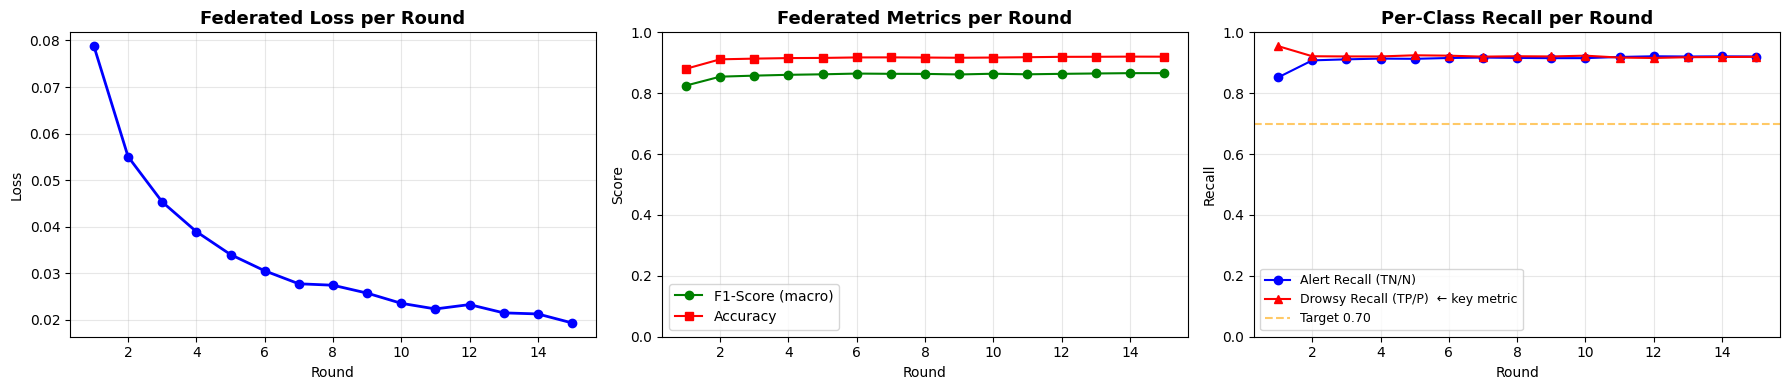

✅ Plot saved as fedprox_training_history.png


In [20]:
if len(subjects_data) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Loss
    axes[0].plot(history['round'], history['loss'], 'b-o', linewidth=2)
    axes[0].set_title('Federated Loss per Round', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Round'); axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    # F1 + Accuracy
    axes[1].plot(history['round'], history['f1'],       'g-o', label='F1-Score (macro)')
    axes[1].plot(history['round'], history['accuracy'], 'r-s', label='Accuracy')
    axes[1].set_title('Federated Metrics per Round', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Round'); axes[1].set_ylabel('Score')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])

    # Per-class recall (new in v3)
    axes[2].plot(history['round'], history['confusion_alert_recall'],
                 'b-o', label='Alert Recall (TN/N)')
    axes[2].plot(history['round'], history['confusion_drowsy_recall'],
                 'r-^', label='Drowsy Recall (TP/P)  ← key metric')
    axes[2].axhline(0.7, color='orange', linestyle='--', alpha=0.6, label='Target 0.70')
    axes[2].set_title('Per-Class Recall per Round', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Round'); axes[2].set_ylabel('Recall')
    axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig('fedprox_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Plot saved as fedprox_training_history.png')

## 🔍 Step 12: Evaluate Best Model + XAI — Attention Analysis


📋 PER-SUBJECT EVALUATION (Best Global Model)
  Subject 0 (01M_1.edf):  Acc=0.934  F1=0.829
              precision    recall  f1-score   support

       Alert       0.92      1.00      0.96       221
      Drowsy       1.00      0.71      0.83        65

    accuracy                           0.93       286
   macro avg       0.96      0.85      0.89       286
weighted avg       0.94      0.93      0.93       286

  Subject 1 (01M_2.edf):  Acc=0.996  F1=0.988
              precision    recall  f1-score   support

       Alert       1.00      1.00      1.00       243
      Drowsy       1.00      0.98      0.99        42

    accuracy                           1.00       285
   macro avg       1.00      0.99      0.99       285
weighted avg       1.00      1.00      1.00       285

  Subject 2 (02F_1.edf):  Acc=0.934  F1=0.899
              precision    recall  f1-score   support

       Alert       1.00      0.91      0.95       204
      Drowsy       0.82      1.00      0.90        85

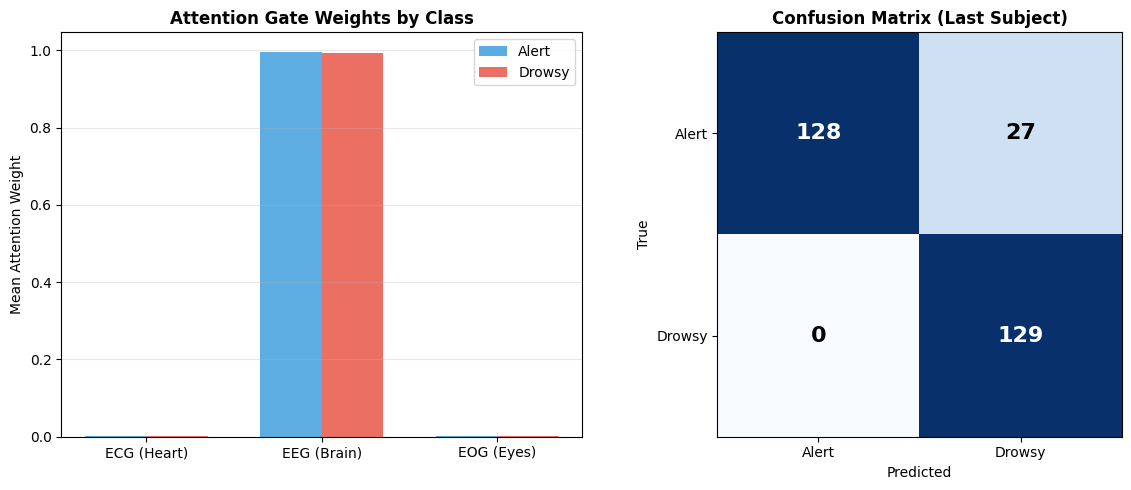

✅ Plot saved as attention_analysis_v3.png


In [21]:
if len(subjects_data) >= 2:
    eval_model.eval()

    print('\n' + '='*65)
    print('📋 PER-SUBJECT EVALUATION (Best Global Model)')
    print('='*65)

    all_attn_alert, all_attn_drowsy = [], []
    last_labels, last_preds = None, None
    global_acc, global_f1 = [], []

    for subj in subjects_data:
        _, te_loader, _ = prepare_loaders(subj, seq_len=SEQ_LEN)
        acc, f1, labels, preds, attn = evaluate(eval_model, te_loader)
        global_acc.append(acc); global_f1.append(f1)
        print(f'  Subject {subj["subject_id"]} ({subj["filename"]}):  '
              f'Acc={acc:.3f}  F1={f1:.3f}')
        print(classification_report(labels, preds,
                                    target_names=['Alert', 'Drowsy'],
                                    zero_division=0))
        all_attn_alert.extend(attn[labels == 0])
        all_attn_drowsy.extend(attn[labels == 1])
        last_labels, last_preds = labels, preds

    print('='*65)
    print(f'📊 GLOBAL AVERAGE:  Acc={np.mean(global_acc):.3f}  F1={np.mean(global_f1):.3f}')
    print('='*65)

    # ── XAI: Attention Weights ────────────────────────────────────────
    modality_names = ['ECG (Heart)', 'EEG (Brain)', 'EOG (Eyes)']
    colors = ['#e74c3c', '#3498db', '#2ecc71']

    if all_attn_alert and all_attn_drowsy:
        mean_alert  = np.mean(all_attn_alert,  axis=0)
        mean_drowsy = np.mean(all_attn_drowsy, axis=0)

        print('\n🔍 XAI: Average attention weights')
        for i, name in enumerate(modality_names):
            print(f'    {name}: Alert={mean_alert[i]:.3f}  Drowsy={mean_drowsy[i]:.3f}')

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        x = np.arange(3); w = 0.35
        axes[0].bar(x - w/2, mean_alert,  w, label='Alert',  color='#3498db', alpha=0.8)
        axes[0].bar(x + w/2, mean_drowsy, w, label='Drowsy', color='#e74c3c', alpha=0.8)
        axes[0].set_xticks(x); axes[0].set_xticklabels(modality_names, fontsize=10)
        axes[0].set_ylabel('Mean Attention Weight')
        axes[0].set_title('Attention Gate Weights by Class', fontweight='bold')
        axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

        if last_labels is not None:
            cm = confusion_matrix(last_labels, last_preds)
            axes[1].imshow(cm, cmap='Blues')
            for i in range(2):
                for j in range(2):
                    axes[1].text(j, i, str(cm[i, j]), ha='center', va='center',
                                 fontsize=16, fontweight='bold',
                                 color='white' if cm[i, j] > cm.max()/2 else 'black')
            axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
            axes[1].set_xticklabels(['Alert', 'Drowsy'])
            axes[1].set_yticklabels(['Alert', 'Drowsy'])
            axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
            axes[1].set_title('Confusion Matrix (Last Subject)', fontweight='bold')

        plt.tight_layout()
        plt.savefig('attention_analysis_v3.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('✅ Plot saved as attention_analysis_v3.png')

## 💾 Step 13: Save Best Model

In [22]:
if len(subjects_data) >= 2:
    torch.save({
        'model_state_dict': eval_model.state_dict(),
        'model_dims':       MODEL_DIMS,
        'seq_len':          SEQ_LEN,
        'num_rounds':       NUM_ROUNDS,
        'mu':               MU,
        'history':          history,
        'best_f1':          max(history['f1']),
    }, 'FedBioXAI_v3_BestModel.pt')
    print('✅ Best model saved: FedBioXAI_v3_BestModel.pt')
    print(f'   Best F1  : {max(history["f1"]):.3f}')
    print(f'   Best Acc : {history["accuracy"][history["f1"].index(max(history["f1"]))]:.3f}')

✅ Best model saved: FedBioXAI_v3_BestModel.pt
   Best F1  : 0.866
   Best Acc : 0.920


## ⚡ Step 14: Real-Time Inference

In [23]:
@torch.no_grad()
def predict_drowsiness_realtime(ecg_windows, eeg_o1_windows, eeg_o2_windows,
                                eog_loc_windows, eog_roc_windows,
                                model, scalers, fs=128):
    """
    Predict drowsiness from a sequence of SEQ_LEN consecutive 30s windows.

    Parameters:
        *_windows : list of SEQ_LEN numpy arrays, each of length window_sec * fs
        model     : trained FedDrowsinessModel (v3)
        scalers   : tuple (sc_ecg, sc_eeg, sc_eog)
    """
    sc_ecg, sc_eeg, sc_eog = scalers
    model.eval()

    ecg_seq, eeg_seq, eog_seq = [], [], []
    for ecg_w, eeg1_w, eeg2_w, eog1_w, eog2_w in zip(
            ecg_windows, eeg_o1_windows, eeg_o2_windows,
            eog_loc_windows, eog_roc_windows):
        ef = np.array(list(extract_ecg_features(ecg_w, fs).values()), dtype=np.float32)
        gf = np.array(list({
            **extract_eeg_features(eeg1_w, fs),
            **{f'o2_{k}': v for k, v in extract_eeg_features(eeg2_w, fs).items()}
        }.values()), dtype=np.float32)
        of = np.array(list({
            **extract_eog_features(eog1_w, fs),
            **{f'roc_{k}': v for k, v in extract_eog_features(eog2_w, fs).items()}
        }.values()), dtype=np.float32)
        ecg_seq.append(ef); eeg_seq.append(gf); eog_seq.append(of)

    ecg_seq = np.array(ecg_seq, dtype=np.float32)
    eeg_seq = np.array(eeg_seq, dtype=np.float32)
    eog_seq = np.array(eog_seq, dtype=np.float32)

    ecg_t = torch.tensor(sc_ecg.transform(ecg_seq)[np.newaxis]).to(device)  # (1, T, feat)
    eeg_t = torch.tensor(sc_eeg.transform(eeg_seq)[np.newaxis]).to(device)
    eog_t = torch.tensor(sc_eog.transform(eog_seq)[np.newaxis]).to(device)

    logits, attn = model(ecg_t, eeg_t, eog_t)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    attn  = attn[0].cpu().numpy()

    drowsy_prob = float(probs[1])
    level = ('🔴 HIGH RISK'  if drowsy_prob > 0.7
              else '🟡 MODERATE' if drowsy_prob > 0.5
              else '🟢 ALERT')

    return {
        'drowsy_prob':  drowsy_prob,
        'alert_prob':   float(probs[0]),
        'prediction':   'DROWSY' if drowsy_prob > 0.5 else 'ALERT',
        'alert_level':  level,
        'attention_weights': {
            'ECG (Heart)': float(attn[0]),
            'EEG (Brain)': float(attn[1]),
            'EOG (Eyes)':  float(attn[2]),
        }
    }

print('✅ Real-time prediction function ready (sequence-aware)')

✅ Real-time prediction function ready (sequence-aware)


## 🧪 Step 15: Test Real-Time Prediction

In [24]:
if len(subjects_data) >= 2 and len(all_signals) > 0:
    _, _, test_scalers = prepare_loaders(subjects_data[0], seq_len=SEQ_LEN)
    test_sig  = all_signals[0]
    test_info = file_info[0]

    ecg  = get_channel(test_sig, REQUIRED_CH['ecg'])
    eeg1 = get_channel(test_sig, REQUIRED_CH['eeg1'])
    eeg2 = get_channel(test_sig, REQUIRED_CH['eeg2'])
    eog1 = get_channel(test_sig, REQUIRED_CH['eog1'])
    eog2 = get_channel(test_sig, REQUIRED_CH['eog2'])

    dur = int(test_info['duration_sec'])
    win = WINDOW_SEC * FS

    print('\n' + '='*65)
    print('⚡ REAL-TIME PREDICTION TEST (sequence-aware)')
    print('='*65)

    np.random.seed(42)
    for i in range(5):
        # Need SEQ_LEN consecutive windows — start at a random offset
        t_end = np.random.randint(SEQ_LEN * STRIDE_SEC + WINDOW_SEC, dur - WINDOW_SEC)
        ecg_wins, eeg1_wins, eeg2_wins, eog1_wins, eog2_wins = [], [], [], [], []
        for k in range(SEQ_LEN):
            t_k = t_end - (SEQ_LEN - 1 - k) * STRIDE_SEC
            s, e = t_k * FS, t_k * FS + win
            ecg_wins.append(ecg[s:e]);   eeg1_wins.append(eeg1[s:e])
            eeg2_wins.append(eeg2[s:e]); eog1_wins.append(eog1[s:e])
            eog2_wins.append(eog2[s:e])

        result = predict_drowsiness_realtime(
            ecg_wins, eeg1_wins, eeg2_wins, eog1_wins, eog2_wins,
            eval_model, test_scalers
        )

        # EEG-derived ground truth for the last window
        s_last = t_end * FS; e_last = t_end * FS + win
        score = eeg_drowsiness_score(eeg1[s_last:e_last], eeg2[s_last:e_last], FS)
        true_state = 'DROWSY' if score >= subjects_data[0]['eeg_threshold'] else 'ALERT'

        print(f'\n📍 Sequence ending @ {t_end}s ({t_end/60:.1f} min)')
        print(f'   True EEG state : {true_state:7s}  |  Predicted: {result["prediction"]}')
        print(f'   Drowsy probability: {result["drowsy_prob"]:.1%}')
        print(f'   Status: {result["alert_level"]}')
        print(f'   Attention → ECG:{result["attention_weights"]["ECG (Heart)"]:.2f}  '
              f'EEG:{result["attention_weights"]["EEG (Brain)"]:.2f}  '
              f'EOG:{result["attention_weights"]["EOG (Eyes)"]:.2f}')


⚡ REAL-TIME PREDICTION TEST (sequence-aware)

📍 Sequence ending @ 920s (15.3 min)
   True EEG state : ALERT    |  Predicted: ALERT
   Drowsy probability: 0.0%
   Status: 🟢 ALERT
   Attention → ECG:0.00  EEG:1.00  EOG:0.00

📍 Sequence ending @ 5450s (90.8 min)
   True EEG state : ALERT    |  Predicted: ALERT
   Drowsy probability: 0.0%
   Status: 🟢 ALERT
   Attention → ECG:0.00  EEG:1.00  EOG:0.00

📍 Sequence ending @ 5286s (88.1 min)
   True EEG state : ALERT    |  Predicted: ALERT
   Drowsy probability: 0.0%
   Status: 🟢 ALERT
   Attention → ECG:0.00  EEG:1.00  EOG:0.00

📍 Sequence ending @ 5251s (87.5 min)
   True EEG state : ALERT    |  Predicted: ALERT
   Drowsy probability: 0.0%
   Status: 🟢 ALERT
   Attention → ECG:0.00  EEG:1.00  EOG:0.00

📍 Sequence ending @ 3832s (63.9 min)
   True EEG state : ALERT    |  Predicted: ALERT
   Drowsy probability: 0.0%
   Status: 🟢 ALERT
   Attention → ECG:0.00  EEG:1.00  EOG:0.00


## 📋 Summary

In [25]:
if len(subjects_data) >= 2:
    best_round = history['f1'].index(max(history['f1'])) + 1
    print('\n' + '='*65)
    print('📊 FedBioXAI v3 — SUMMARY')
    print('='*65)
    print(f'  Dataset            : DD Drowsiness (EDF files in "{EDF_FOLDER}/")')
    print(f'  Subjects loaded    : {len(subjects_data)}')
    print(f'  Labels             : EEG theta/alpha ratio (adaptive per-subject threshold)')
    print(f'  Architecture       : Expert Networks + Attention Gate + Temporal LSTM')
    print(f'  Training           : FedProx (mu={MU}, {NUM_ROUNDS} rounds)')
    print(f'  Sequence length    : {SEQ_LEN} windows ({SEQ_LEN * STRIDE_SEC}s temporal context)')
    print(f'  Best round         : {best_round}')
    print(f'  Best F1            : {max(history["f1"]):.3f}')
    print(f'  Best Accuracy      : {history["accuracy"][best_round-1]:.3f}')
    print(f'  Best Drowsy Recall : {history["confusion_drowsy_recall"][best_round-1]:.3f}')
    print('='*65)
    print("""
  Improvements over v2:
    ✅ Real EEG-derived labels  → better F1 on drowsy class
    ✅ FedProx                  → stable convergence across non-IID subjects
    ✅ Temporal LSTM            → captures progressive drowsiness onset
    ✅ Per-round drowsy recall  → safety-critical metric now tracked
    ✅ Best-checkpoint saving   → returns round with highest F1, not just last
""")


📊 FedBioXAI v3 — SUMMARY
  Dataset            : DD Drowsiness (EDF files in "lol/")
  Subjects loaded    : 20
  Labels             : EEG theta/alpha ratio (adaptive per-subject threshold)
  Architecture       : Expert Networks + Attention Gate + Temporal LSTM
  Training           : FedProx (mu=0.01, 15 rounds)
  Sequence length    : 6 windows (30s temporal context)
  Best round         : 15
  Best F1            : 0.866
  Best Accuracy      : 0.920
  Best Drowsy Recall : 0.920

  Improvements over v2:
    ✅ Real EEG-derived labels  → better F1 on drowsy class
    ✅ FedProx                  → stable convergence across non-IID subjects
    ✅ Temporal LSTM            → captures progressive drowsiness onset
    ✅ Per-round drowsy recall  → safety-critical metric now tracked
    ✅ Best-checkpoint saving   → returns round with highest F1, not just last

